In [6]:
import pandas as pd
import json

In [12]:
df = pd.read_csv("../../outputs/pos/part_of_speech.csv")
df_sentiment = pd.read_csv("../../preprocessed/dataset_preprocessed_bert.csv")

df["manual sentiment"] = df_sentiment["manual sentiment"]
df

,url,judul,konten,konten_clean,tokens_json,manual sentiment
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",jakarta cnbc indonesia amerika serikat as seca...,"[[""jakarta"", ""PROPN""], [""cnbc"", ""PROPN""], [""in...",Positive
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",jakarta cnbc indonesia nilai tukar rupiah terh...,"[[""jakarta"", ""PROPN""], [""cnbc"", ""PROPN""], [""in...",Positive
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",jakarta cnbc indonesia pasar keuangan indonesi...,"[[""jakarta"", ""PROPN""], [""cnbc"", ""PROPN""], [""in...",Positive
3,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",jakarta cnbc indonesia indeks harga saham gabu...,"[[""jakarta"", ""PROPN""], [""cnbc"", ""PROPN""], [""in...",Negative
4,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,hargabitcoin btc pernah melewati angka terting...,"[[""hargabitcoin"", ""PROPN""], [""btc"", ""PROPN""], ...",Positive
...,...,...,...,...,...,...
994,https://voi.id/teknologi/489452/produsen-mesin...,Produsen Mesin Bitcoin China Pindahkan Produks...,JAKARTA - Tiga produsen mesin penambang bitcoi...,jakarta tiga produsen mesin penambang bitcoin ...,"[[""jakarta"", ""PROPN""], [""tiga"", ""NUM""], [""prod...",Positive
995,https://www.liputan6.com/bisnis/read/6058462/d...,Donald Trump Kembali Tekan Ketua The Fed Jerom...,Presiden Amerika Serikat (AS) Donald Trump men...,presiden amerika serikat as donald trump menga...,"[[""presiden"", ""NOUN""], [""amerika"", ""PROPN""], [...",Neutral
996,https://kabar24.bisnis.com/read/20250622/19/18...,"Donald Trump Serang Iran, Ekonomi Global Bakal...","Bisnis.com,JAKARTA — Serangan Amerika Serikat ...",bisnis com jakarta serangan amerika serikat as...,"[[""bisnis"", ""NOUN""], [""com"", ""PROPN""], [""jakar...",Negative
997,https://www.cnbcindonesia.com/tech/20250620153...,Trump 'Palak' Raksasa Teknologi Rp 900 Triliun...,"Jakarta, CNBC Indonesia -Perusahaan semikonduk...",jakarta cnbc indonesia perusahaan semikondukto...,"[[""jakarta"", ""PROPN""], [""cnbc"", ""PROPN""], [""in...",Negative


In [17]:

df["tokens_parsed"] = df["tokens_json"].apply(
    lambda x: [tuple(item) for item in json.loads(x)] if pd.notna(x) else []
)

df[["manual sentiment", "tokens_parsed"]].head(10)

,manual sentiment,tokens_parsed
0,Positive,"[(jakarta, PROPN), (cnbc, PROPN), (indonesia, ..."
1,Positive,"[(jakarta, PROPN), (cnbc, PROPN), (indonesia, ..."
2,Positive,"[(jakarta, PROPN), (cnbc, PROPN), (indonesia, ..."
3,Negative,"[(jakarta, PROPN), (cnbc, PROPN), (indonesia, ..."
4,Positive,"[(hargabitcoin, PROPN), (btc, PROPN), (pernah,..."
5,Negative,"[(jakarta, PROPN), (cnbc, PROPN), (indonesia, ..."
6,Negative,"[(kebijakan, NOUN), (tarif, NOUN), (impor, NOU..."
7,Positive,"[(keputusan, NOUN), (mendadak, ADJ), (presiden..."
8,Positive,"[(bisnis, NOUN), (com, PROPN), (jakarta, NOUN)..."
9,Neutral,"[(jakarta, PROPN), (cnbc, PROPN), (indonesia, ..."


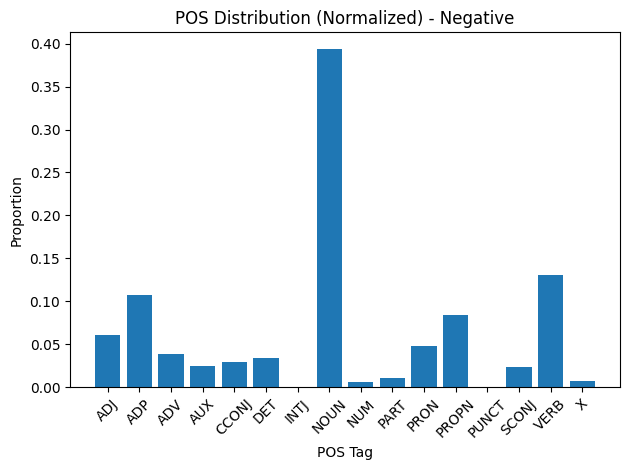

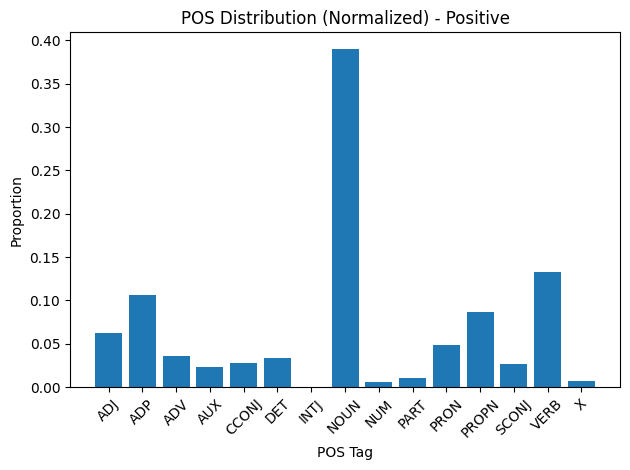

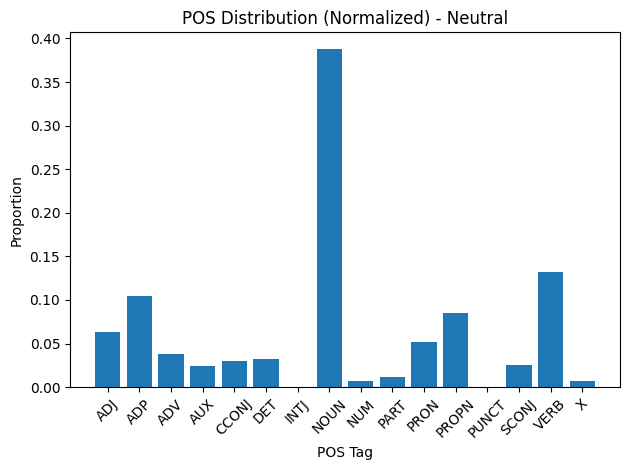

In [20]:
import matplotlib.pyplot as plt
from collections import Counter

def get_pos_counts(sentiment_label):
    subset = df[df["manual sentiment"] == sentiment_label]
    
    pos_counter = Counter()
    
    for tokens in subset["tokens_parsed"]:
        for _, pos in tokens:
            pos_counter[pos] += 1
            
    return pos_counter

sentiments = ["Negative", "Positive", "Neutral"]

for sentiment in sentiments:
    pos_counts = get_pos_counts(sentiment)
    
    # sort alphabetically
    sorted_items = sorted(pos_counts.items())
    labels = [k for k, v in sorted_items]
    values = [v for k, v in sorted_items]
    
    # normalize
    total = sum(values)
    values = [v / total for v in values] if total > 0 else values
    
    plt.figure()
    plt.bar(labels, values)
    plt.title(f"POS Distribution (Normalized) - {sentiment}")
    plt.xlabel("POS Tag")
    plt.ylabel("Proportion")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

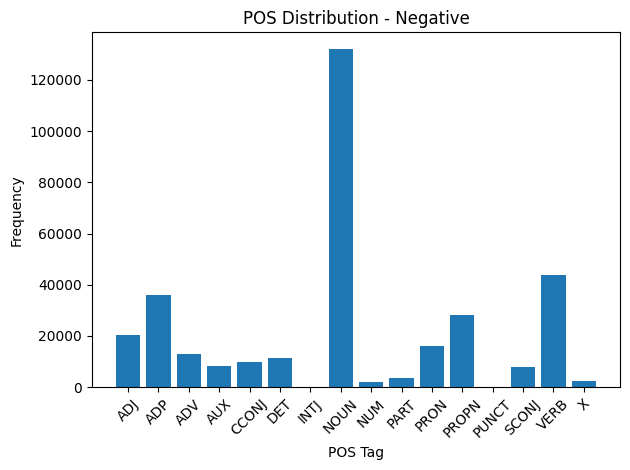

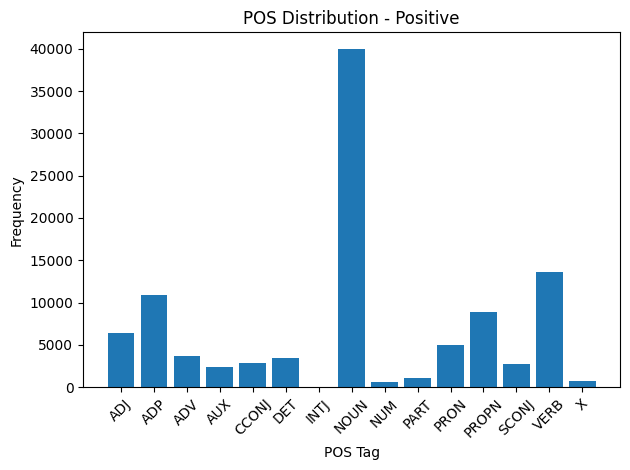

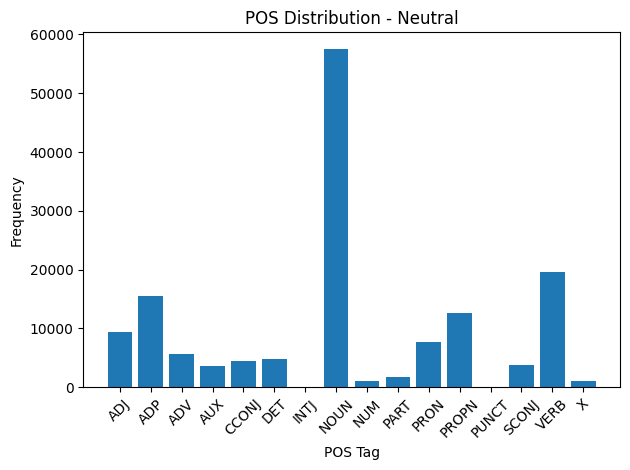

In [21]:
import matplotlib.pyplot as plt
from collections import Counter

def get_pos_counts(sentiment_label):
    subset = df[df["manual sentiment"] == sentiment_label]
    
    pos_counter = Counter()
    
    for tokens in subset["tokens_parsed"]:
        for _, pos in tokens:
            pos_counter[pos] += 1
            
    return pos_counter

sentiments = ["Negative", "Positive", "Neutral"]

for sentiment in sentiments:
    pos_counts = get_pos_counts(sentiment)
    
    # sort alphabetically by POS tag
    sorted_items = sorted(pos_counts.items())
    labels = [k for k, v in sorted_items]
    values = [v for k, v in sorted_items]
    
    plt.figure()
    plt.bar(labels, values)
    plt.title(f"POS Distribution - {sentiment}")
    plt.xlabel("POS Tag")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()